In [1]:
import time
start_time = time.time()
print("Notebook execution started...")

Notebook execution started...


In [2]:
import requests  
from bs4 import BeautifulSoup 
import pandas as pd
import numpy as np

!pip install pandas geocoder geopy 
import geocoder
from geopy.geocoders import Nominatim
import folium

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt


import matplotlib.cm as cm
import matplotlib.colors as colors

import seaborn as sns

!pip install adjustText
from adjustText import adjust_text

# Data Acquisition

# Geographic Data


In [3]:
URL of the Wikipedia page
wiki_url = "https://en.wikipedia.org/wiki/List_of_neighbourhoods_of_Delhi"

# Fetch the content of the page
response = requests.get(wiki_url)

# Parse the HTML content with BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Find all unordered lists in the content (neighborhoods are listed in <ul> tags)
lists = soup.find_all('ul')

# Placeholder for neighborhood names
neighbourhoods = []

# Iterate through lists to find relevant ones
for ul in lists:
    # Extract list items
    items = ul.find_all('li')
    for item in items:
        # Get the text of each list item
        name = item.text.strip()
        
        # Optional: Filter by valid neighborhood names
        if name and not name.startswith('See also') and not name.startswith('References'):
            neighbourhoods.append(name)

# Remove duplicates (if any) and clean data
neighbourhoods = list(set(neighbourhoods))

# Convert to a pandas DataFrame
df_neighbourhoods = pd.DataFrame(neighbourhoods, columns=['Neighbourhood'])

# Save the DataFrame to an Excel file
df_neighbourhoods.to_excel('neighbourhoods_of_delhi.xlsx', index=False)

# print("Data has been successfully saved to 'neighbourhoods_of_delhi.xlsx'


Geographical coordinates for the neighbourhoods of delhi

In [4]:
# Load the Excel file into a DataFrame
df_neighbourhoods = pd.read_excel('neighbourhoods_of_delhi.xlsx')

# Placeholder for latitude and longitude
latitudes = []
longitudes = []

# Fetch coordinates for each neighborhood
for neighbourhood in df_neighbourhoods['Neighbourhood']:
    g = geocoder.arcgis(neighbourhood + ", Delhi, India")  
    if g.ok:
        latitudes.append(g.latlng[0])  # Latitude
        longitudes.append(g.latlng[1])  # Longitude
    else:
        latitudes.append(None)
        longitudes.append(None)
#     print(f"Processed: {neighbourhood} -> {g.latlng}")

# Add coordinates to the DataFrame
df_neighbourhoods['Latitude'] = latitudes
df_neighbourhoods['Longitude'] = longitudes

# # Save the updated DataFrame to a new Excel file
# df_neighbourhoods.to_excel('neighbourhoods.xlsx', index=False)

print("Coordinates have been added")

In [5]:
# Loading Excel file into a DataFrame
df_neighbourhoods = pd.read_excel("C:/Users/himde/OneDrive/BITS_DS/BITS_DS 4_sem/Mid_sem_V3/neighbourhoods_coordinates.xlsx")

print(df_neighbourhoods.head())


  Neighbourhood          District   Latitude  Longitude
0  Adarsh Nagar  North West Delhi  28.719393  77.173273
1   Ashok Vihar  North West Delhi  28.689766  77.175230
2  Keshav Puram  North West Delhi  28.682776  77.159267
3     Pitampura  North West Delhi  28.695094  77.130706
4        Rohini  North West Delhi  28.701868  77.098360


In [6]:
df_neighbourhoods.isnull().sum()

Neighbourhood    0
District         0
Latitude         0
Longitude        0
dtype: int64

In [7]:
df_neighbourhoods.describe(include='object')

,Neighbourhood,District
count,160,160
unique,153,9
top,Munirka,South Delhi
freq,2,51


In [8]:
df_neighbourhoods.describe()

,Latitude,Longitude
count,160.000000,160.000000
mean,28.612690,77.196482
std,0.058707,0.074006
min,28.493385,76.982407
25%,28.566381,77.147779
50%,28.617515,77.207560
75%,28.651734,77.252142
max,28.755170,77.319589


In [9]:
# create map of delhi using latitude and longitude values
map_delhi = folium.Map(location=[28.6139, 77.2090], zoom_start=11)

# add markers to map
for lat, lng, label in zip(df_neighbourhoods['Latitude'], df_neighbourhoods['Longitude'], df_neighbourhoods['Neighbourhood']):
    folium.CircleMarker(
        [lat, lng],
        radius=5,
        #popup=label,
        color='green',
        fill=True,
        fill_color='#3186cc',
        fill_opacity=0.7,
        parse_html=False).add_to(map_delhi)  
    
map_delhi

In [11]:
# Function to find venues in a given neighbourhood
def getNearbyVenues(names, latitudes, longitudes, radius=500):
    
    venues_list=[]
    for name, lat, lng in zip(names, latitudes, longitudes):
            
        # create the API request URL
        url = 'https://api.foursquare.com/v2/venues/search?&client_id={}&client_secret={}&v={}&ll={},{}&radius={}&limit={}'.format(
            CLIENT_ID, 
            CLIENT_SECRET, 
            VERSION, 
            lat, 
            lng,
            radius, 
            LIMIT)
            
       
        results = requests.get(url).json()["response"]['venues']

        # return information 
        venues_list.append([(
            name, 
            lat, 
            lng, 
            v['name'], 
            v['location']['lat'], 
            v['location']['lng'],  
            v['categories'][0]['name']) for v in results if v['categories']])

    nearby_venues = pd.DataFrame([item for venue_list in venues_list for item in venue_list])
    nearby_venues.columns = ['Neighbourhood', 
                  'Neighbourhood Latitude', 
                  'Neighbourhood Longitude', 
                  'Venue', 
                  'Venue Latitude', 
                  'Venue Longitude', 
                  'Venue Category']
    
    return(nearby_venues)

In [12]:
# # Search for venues within 1Km of radius from the neighbourhood centre point
# radius = 1000

# delhi_venues = getNearbyVenues(names=df_neighbourhoods['Neighbourhood'],
#                                    latitudes=df_neighbourhoods['Latitude'],
#                                    longitudes=df_neighbourhoods['Longitude'],
#                                    radius=radius)

# print(delhi_venues.shape)
# delhi_venues.to_excel("Delhi_Nearby_Venues.xlsx", index=False)

# print("Excel file saved: Delhi_Nearby_Venues.xlsx")
# delhi_venues.head()

In [13]:
# Loading venues data file into a DataFrame
delhi_venues = pd.read_excel("C:/Users/himde/OneDrive/BITS_DS/BITS_DS 4_sem/Mid_sem_V3/Delhi_Nearby_Venues.xlsx")

print(delhi_venues.head())

  Neighbourhood  Neighbourhood Latitude  Neighbourhood Longitude  \
0  Adarsh Nagar               28.719393                77.173273   
1  Adarsh Nagar               28.719393                77.173273   
2  Adarsh Nagar               28.719393                77.173273   
3  Adarsh Nagar               28.719393                77.173273   
4  Adarsh Nagar               28.719393                77.173273   

                                               Venue  Venue Latitude  \
0           Jahangirpuri Metro Station | जहांगीरपुरी       28.726026   
1                    Azadpur | आजादपुर Metro Station       28.706911   
2                                        Lakmé Salon       28.710677   
3                                    Fortis Hospital       28.708790   
4  Fortis Hospital | फोर्टिस अस्पताल , Shalimar Bagh       28.709445   

   Venue Longitude Venue Category  
0        77.162626  Metro Station  
1        77.180846  Metro Station  
2        77.160118     Hair Salon  
3        77.16

In [14]:
delhi_venues.describe(include='object')

,Neighbourhood,Venue,Venue Category
count,6860,6860,6860
unique,153,4320,438
top,Lodhi Colony,HDFC Bank ATM,ATM
freq,100,258,332


In [15]:
delhi_venues.describe()

,Neighbourhood Latitude,Neighbourhood Longitude,Venue Latitude,Venue Longitude
count,6860.000000,6860.000000,6860.000000,6860.000000
mean,28.612248,77.195843,28.609454,77.195844
std,0.066903,0.105798,0.200691,0.106118
min,25.891631,76.982407,12.913894,76.976475
25%,28.566234,77.141534,28.564218,77.143777
50%,28.619064,77.206617,28.618405,77.207275
75%,28.651464,77.251858,28.652475,77.248184
max,28.755170,83.457543,28.782032,83.547223


In [16]:
delhi_venues.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6860 entries, 0 to 6859
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Neighbourhood            6860 non-null   object 
 1   Neighbourhood Latitude   6860 non-null   float64
 2   Neighbourhood Longitude  6860 non-null   float64
 3   Venue                    6860 non-null   object 
 4   Venue Latitude           6860 non-null   float64
 5   Venue Longitude          6860 non-null   float64
 6   Venue Category           6860 non-null   object 
dtypes: float64(4), object(3)
memory usage: 375.3+ KB


Analysing each neighbourhood

In [17]:
# one hot encoding
delhi_onehot = pd.get_dummies(delhi_venues[['Venue Category']], prefix="", prefix_sep="")

# add neighbourhood column back to dataframe
delhi_onehot['Neighbourhood'] = delhi_venues['Neighbourhood'] 

fixed_columns = [delhi_onehot.columns[-1]] + list(delhi_onehot.columns[:-1])
delhi_onehot = delhi_onehot[fixed_columns]

print(f'Size: {delhi_onehot.shape}')
delhi_onehot.head()

Size: (6860, 439)


,Neighbourhood,ATM,Adult Education,Advertising Agency,Afghan Restaurant,Airport,Airport Gate,Airport Lounge,Airport Service,Airport Terminal,...,Wedding Hall,Well,Whisky Bar,Wholesaler,Wine Bar,Wine Store,Wings Joint,Women's Store,Yoga Studio,Zoo Exhibit
0,Adarsh Nagar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Adarsh Nagar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Adarsh Nagar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Adarsh Nagar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Adarsh Nagar,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Grouping rows by neighbourhood and finding frequency of each category

In [18]:
delhi_grouped = delhi_onehot.groupby('Neighbourhood').mean().reset_index()
print(f'Size: {delhi_grouped.shape}')
delhi_grouped.head()

Size: (153, 439)


,Neighbourhood,ATM,Adult Education,Advertising Agency,Afghan Restaurant,Airport,Airport Gate,Airport Lounge,Airport Service,Airport Terminal,...,Wedding Hall,Well,Whisky Bar,Wholesaler,Wine Bar,Wine Store,Wings Joint,Women's Store,Yoga Studio,Zoo Exhibit
0,Adarsh Nagar,0.190476,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
1,Aerocity,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.020408,0.0,0.0,0.0,0.000000,0.0
2,Akshardham,0.022222,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.022222,0.0
3,Alaknanda,0.073171,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,Anand Vihar,0.048780,0.0,0.0,0.0,0.0,0.02439,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


# Demographhic Data

Population dataset

In [19]:
# Load data from population file
df_delhi_population = pd.read_excel("C:/Users/himde/OneDrive/BITS_DS/BITS_DS 4_sem/Mid_sem_V3/Neighbourhood_population.xlsx", header=3, names=[ 'Neighbourhood', 'Population'], converters={'Total': int})
print(df_delhi_population.shape)
df_delhi_population.head()

(156, 2)


,Neighbourhood,Population
0,Alaknanda,86546
1,Anand Vihar,69183
2,Aruna Nagar,4718
3,Ashok Nagar,59850
4,Ashok Vihar,55773


Average monthly expense of each neighbourhood

In [20]:
# Load data from file taking into account the table headers are on the 4th row and the population need to be converted to integer.
df_ame = pd.read_excel("C:/Users/himde/OneDrive/BITS_DS/BITS_DS 4_sem/Mid_sem_V3/Avg_monthly_expense.xlsx", names=['Neighbourhood',  'Average Monthly Expense'], converters={'Income': int})
print(df_ame.shape)
df_ame.head()

(159, 2)


,Neighbourhood,Average Monthly Expense
0,Adarsh Nagar,22000
1,Aerocity,20000
2,Akshardham,25000
3,Alaknanda,35000
4,Anand Vihar,25000


In [21]:
# Category ID in Foursquare API
supermarket_category = '52f2ab2ebcbc57f1066b8b46'
radius= 1000
# Function to count the number of market-like venues in a given neighbourhood
def getMarketVenues(row):
    
    # create the API request URL
    url = 'https://api.foursquare.com/v2/venues/search?&client_id={}&client_secret={}&v={}&ll={},{}&categoryId={}&radius={}&limit={}'.format(
        CLIENT_ID, 
        CLIENT_SECRET, 
        VERSION, 
        row['Latitude'], 
        row['Longitude'],
        supermarket_category,
        radius, 
        LIMIT)

    # make the GET request and get length of venues
    count = len(requests.get(url).json()["response"]['venues'])

    # return count
    return pd.Series(count)

# Neighbourhood segmentation

# Kmeans Clustering

In [22]:
# Function for sorting the venues in descencing order
def return_most_common_venues(row, num_top_venues):
    row_categories = row.iloc[1:]
    row_categories_sorted = row_categories.sort_values(ascending=False)
    
    return row_categories_sorted.index.values[0:num_top_venues]

In [23]:
num_top_venues = 10

indicators = ['st', 'nd', 'rd']

# create columns according to number of top venues
columns = ['Neighbourhood']
for ind in np.arange(num_top_venues):
    try:
        columns.append('{}{} Most Common Venue'.format(ind+1, indicators[ind]))
    except:
        columns.append('{}th Most Common Venue'.format(ind+1))

# create new dataframe
neighbourhoods_venues_sorted = pd.DataFrame(columns=columns)
neighbourhoods_venues_sorted['Neighbourhood'] = delhi_grouped['Neighbourhood']

for ind in np.arange(delhi_grouped.shape[0]):
    neighbourhoods_venues_sorted.iloc[ind, 1:] = return_most_common_venues(delhi_grouped.iloc[ind, :], num_top_venues)

neighbourhoods_venues_sorted.head()

,Neighbourhood,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
1,Aerocity,Indian Restaurant,Restaurant,North Indian Restaurant,Mughlai Restaurant,Metro Station,Café,Hotel,Coffee Shop,Donut Shop,Bakery
2,Akshardham,Apartment or Condo,Indian Restaurant,Market,Education,Hair Salon,Travel and Transportation,Structure,Gym and Studio,Government Building,Eyecare Store
3,Alaknanda,ATM,Indian Restaurant,Apartment or Condo,Education,Pharmacy,Fast Food Restaurant,Chinese Restaurant,Tea Room,Health and Beauty Service,Bar
4,Anand Vihar,Restaurant,ATM,Park,Coffee Shop,Department Store,Diner,Apartment or Condo,Clothing Store,Pizzeria,Parking


In [24]:
import warnings

# Suppress specific warning by category
warnings.filterwarnings("ignore", category=UserWarning)

# Example: Code that triggers a UserWarning
warnings.warn("This is a user warning!", UserWarning)


1 

C:\Users\himde\AppData\Local\Temp\ipykernel_28152\3344445502.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  delhi_grouped_clustering = delhi_grouped.drop('Neighbourhood', 1)


2 3 4 5 6 7 8 9 

Text(0.5, 1.0, 'Elbow Method For Optimal k')

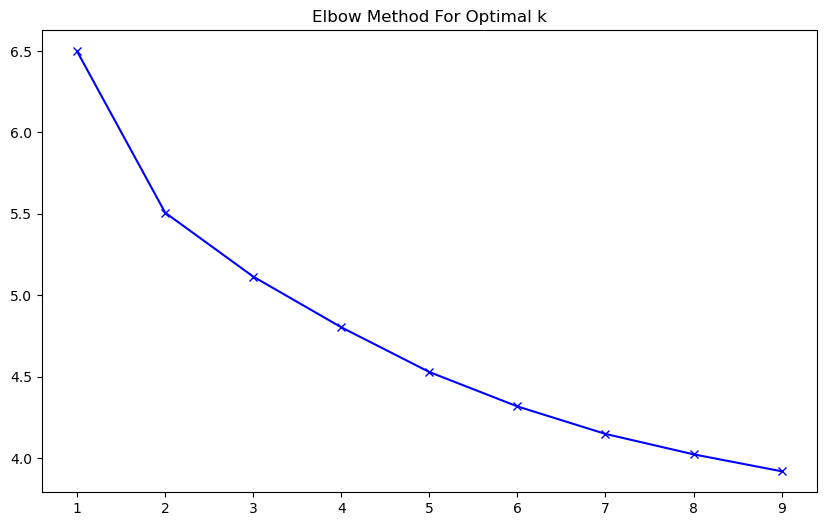

In [25]:
# Elbow method for clustering
delhi_grouped_clustering = delhi_grouped.drop('Neighbourhood', 1)
sum_of_squared_distances = []

K = range(1,10)

for k in K:
    print(k, end=' ')
    kmeans = KMeans(n_clusters=k, random_state=50, n_init=20).fit(delhi_grouped_clustering)
    sum_of_squared_distances.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.title('Elbow Method For Optimal k')

In [26]:
# set number of clusters is 5 
kclusters = 5

kmeans = KMeans(n_clusters=kclusters, random_state=42).fit(delhi_grouped_clustering)

kmeans.labels_[0:10]

C:\Users\himde\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([3, 2, 2, 2, 2, 1, 3, 3, 1, 3])

# Creating a dataframe with cluster labels and top venues

In [27]:
# Remove the column if it exists
if 'Cluster Labels' in neighbourhoods_venues_sorted.columns:
    neighbourhoods_venues_sorted.drop(columns=['Cluster Labels'], inplace=True)

# add clustering labels
neighbourhoods_venues_sorted.insert(0, 'Cluster Labels', kmeans.labels_)

delhi_merged = df_neighbourhoods

delhi_merged = delhi_merged.join(neighbourhoods_venues_sorted.set_index('Neighbourhood'), on='Neighbourhood')

delhi_merged.head()

,Neighbourhood,District,Latitude,Longitude,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,North West Delhi,28.719393,77.173273,3,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
1,Ashok Vihar,North West Delhi,28.689766,77.175230,3,ATM,Electronics Store,Bank,Pizzeria,Hair Salon,Gym and Studio,Dessert Shop,Butcher,Gym,Temple
2,Keshav Puram,North West Delhi,28.682776,77.159267,3,ATM,Snack Place,Hair Salon,Restaurant,Structure,Metro Station,Repair Service,Flea Market,High School,Miscellaneous Store
3,Pitampura,North West Delhi,28.695094,77.130706,2,Park,ATM,Restaurant,Apartment or Condo,Clothing Store,Pizzeria,Police Station,Health and Beauty Service,Medical Lab,Tattoo Parlor
4,Rohini,North West Delhi,28.701868,77.098360,3,ATM,Apartment or Condo,Fuel Station,Convenience Store,Bank,Miscellaneous Store,Park,Clothing Store,Assisted Living,Donut Shop


Visualizing the Cluster

In [28]:
# create map
map_clusters = folium.Map(location=[28.6139, 77.2090], zoom_start=11)

x = np.arange(kclusters)
ys = [i + x + (i*x)**2 for i in range(kclusters)]
colors_array = cm.rainbow(np.linspace(0, 1, len(ys)))
rainbow = [colors.rgb2hex(i) for i in colors_array]

# add markers to the map
markers_colors = []
for lat, lon, area, cluster in zip(delhi_merged['Latitude'], delhi_merged['Longitude'], delhi_merged['Neighbourhood'], delhi_merged['Cluster Labels']):

    folium.CircleMarker(
        [lat, lon],
        radius=5,
        popup=label,
        color=rainbow[int(cluster)-1],
        fill=True,
        fill_color=rainbow[int(cluster)-1],
        fill_opacity=0.7).add_to(map_clusters)
       
map_clusters

# Examining clusters

Cluster 0 

In [29]:
delhi_merged.loc[delhi_merged['Cluster Labels'] == 0, delhi_merged.columns[[0] + list(range(4, delhi_merged.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
34,Barakhamba Road,0,Office,Bank,Structure,Tea Room,Indian Restaurant,Coffee Shop,Camera Store,Miscellaneous Store,ATM,Gastropub
38,ITO,0,Structure,Stadium,Government Building,Cemetery,History Museum,Business and Professional Services,Museum,Mosque,Hair Salon,Automotive Repair Shop
40,Jhandewalan,0,Office,ATM,Hotel,Structure,Automotive Repair Shop,Temple,Bank,Bed and Breakfast,Diner,Cultural Center
58,Laxmi Nagar,0,Office,Clothing Store,Apartment or Condo,Fast Food Restaurant,Bank,Dessert Shop,Doctor's Office,Cupcake Shop,Bar,High School
72,Khanpur,0,Structure,Office,Indian Restaurant,ATM,Housing Development,Student Center,Ice Cream Parlor,Other Great Outdoors,Apartment or Condo,Miscellaneous Store
82,Saket,0,Structure,Hotel,Office,Bank,Indian Restaurant,Lounge,Men's Store,Chocolate Store,Comedy Club,Resort
87,South East Delhi,0,Office,Coffee Shop,Indian Restaurant,Structure,Coworking Space,Café,Textiles Store,Gym,Men's Store,Tech Startup
106,Govindpuri,0,Office,ATM,Bank,Pizzeria,Pub,Tech Startup,Structure,Business and Professional Services,Snack Place,Coffee Shop
108,Okhla,0,Office,Automotive Repair Shop,Structure,Art Gallery,Bike Rental,Tech Startup,Car Dealership,Performing Arts Venue,Factory,Breakfast Spot
109,Okhla Phase I,0,Office,Automotive Repair Shop,Indian Restaurant,Structure,Clothing Store,ATM,Café,Housing Development,Business and Professional Services,Car Wash and Detail


Cluster 1

In [30]:
delhi_merged.loc[delhi_merged['Cluster Labels'] == 1, delhi_merged.columns[[0] + list(range(4, delhi_merged.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
16,Majnu-ka-tilla,1,Asian Restaurant,Hotel,Café,ATM,Restaurant,Tibetan Restaurant,Coffee Shop,Korean Restaurant,Bus Station,Office
17,New Aruna Nagar,1,Hotel,Café,Tibetan Restaurant,Restaurant,ATM,Temple,Korean Restaurant,Buddhist Temple,Chinese Restaurant,Gym
18,Aruna Nagar,1,Café,Hotel,Tibetan Restaurant,Restaurant,ATM,Temple,Korean Restaurant,Buddhist Temple,Bus Station,Gym
19,Bhajanpura,1,Travel and Transportation,Pizzeria,Hotel,Clothing Store,Tibetan Restaurant,ATM,Office,Restaurant,Retail,Buddhist Temple
24,Seelampur,1,Tibetan Restaurant,Travel and Transportation,Café,Hotel,ATM,Pizzeria,Buddhist Temple,Office,Retail,Restaurant
28,Karol Bagh,1,Hotel,Jewelry Store,ATM,Clothing Store,Fast Food Restaurant,Fashion Accessories Store,Snack Place,Boutique,Shoe Store,Bank
31,Gole Market,1,Hotel,Indian Restaurant,Office,Hindu Temple,Metro Station,Arts and Crafts Store,ATM,Education,Textiles Store,Bookstore
32,Paharganj,1,Hotel,Bed and Breakfast,Restaurant,Indian Restaurant,Boarding House,Coffee Shop,Gym and Studio,Tennis Court,Church,Board Store
36,Patel Chowk,1,Hotel,Government Building,Metro Station,Bank,Meeting Room,Indian Restaurant,Office,Travel and Transportation,Men's Store,Lounge
37,Janpath,1,Hotel,Metro Station,Spa,Italian Restaurant,Indian Restaurant,Hotel Pool,Event Space,History Museum,Business Center,Travel Agency


Cluster 2

In [31]:
delhi_merged.loc[delhi_merged['Cluster Labels'] == 2, delhi_merged.columns[[0] + list(range(4, delhi_merged.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
3,Pitampura,2,Park,ATM,Restaurant,Apartment or Condo,Clothing Store,Pizzeria,Police Station,Health and Beauty Service,Medical Lab,Tattoo Parlor
8,Civil Lines,2,Metro Station,Pizzeria,Government Building,Hospital,Indian Restaurant,ATM,Bus Stop,High School,Mexican Restaurant,Gym and Studio
9,Kamla Nagar,2,Clothing Store,Men's Store,Snack Place,Fast Food Restaurant,Structure,Indian Restaurant,Miscellaneous Store,Fried Chicken Joint,Restaurant,Retail
12,Model Town,2,Gym,ATM,Clothing Store,Indian Restaurant,Dentist,Ice Cream Parlor,Multicuisine Indian Restaurant,Boutique,Community Center,BBQ Joint
14,GTB Nagar,2,Indian Restaurant,ATM,Coffee Shop,Bakery,Pizzeria,Juice Bar,Café,Ice Cream Parlor,Butcher,Auditorium
...,...,...,...,...,...,...,...,...,...,...,...,...
145,Dwarka Mor,2,Clothing Store,Hotel,Indian Restaurant,Shopping Mall,Jewelry Store,Metro Station,Apartment or Condo,Spa,Restaurant,Indian Sweet Shop
148,Moti Nagar,2,Metro Station,Automotive Repair Shop,Fast Food Restaurant,Convenience Store,Pizzeria,Miscellaneous Store,ATM,Flea Market,Fuel Station,Fried Chicken Joint
151,Punjabi Bagh,2,Indian Restaurant,Lounge,Fast Food Restaurant,Office,Diner,ATM,Gym and Studio,Gym,Electronics Store,Dessert Shop
152,Rajouri Garden,2,Clothing Store,Gym,Ice Cream Parlor,Restaurant,Cosmetics Store,Hair Salon,Shopping Mall,Sikh Temple,Tailor,Coffee Shop


Cluster 3

In [32]:
delhi_merged.loc[delhi_merged['Cluster Labels'] == 3, delhi_merged.columns[[0] + list(range(4, delhi_merged.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,3,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
1,Ashok Vihar,3,ATM,Electronics Store,Bank,Pizzeria,Hair Salon,Gym and Studio,Dessert Shop,Butcher,Gym,Temple
2,Keshav Puram,3,ATM,Snack Place,Hair Salon,Restaurant,Structure,Metro Station,Repair Service,Flea Market,High School,Miscellaneous Store
4,Rohini,3,ATM,Apartment or Condo,Fuel Station,Convenience Store,Bank,Miscellaneous Store,Park,Clothing Store,Assisted Living,Donut Shop
5,Shalimar Bagh,3,ATM,Indian Restaurant,Automotive Repair Shop,Hospital,Gym and Studio,Bank,Convenience Store,Airport Service,Bakery,Temple
6,Shastri Nagar,3,ATM,Bank,Indian Restaurant,Temple,Gym,Office,Fast Food Restaurant,Rail Station,College Gym,Performing Arts Venue
7,Azadpur,3,ATM,Metro Station,Clothing Store,Factory,Fast Food Restaurant,Hospital,Automotive Repair Shop,Indian Restaurant,Bank,Park
10,Kashmiri Gate,3,Fast Food Restaurant,Metro Station,ATM,University,Historic and Protected Site,Fried Chicken Joint,Shopping Mall,Automotive Repair Shop,Hindu Temple,Spa
11,Daryaganj,3,ATM,Bank,North Indian Restaurant,Historic and Protected Site,Restaurant,Indian Restaurant,Metro Station,Hospital,Music Store,Bookstore
13,Sarai Rohilla,3,ATM,Gym,Dentist,Hotel,Bank,Rail Station,Metro Station,Pizzeria,Camera Store,Men's Store


Cluster 4

In [33]:
delhi_merged.loc[delhi_merged['Cluster Labels'] == 4, delhi_merged.columns[[0] + list(range(4, delhi_merged.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
159,Vinobapuri,4,Temple,ATM,Non-Profit Organization,Organic Grocery,Optometrist,Office Supply Store,Office Building,Office,Nutritionist,Nursery School


Choosing a residential cluster

In [34]:
# List of residential-related venues
residential_buildings = [
    "ATM", "Indian Restaurant", "Apartment or Condo", "Pizzeria", "Gym",
    "Hair Salon", "Gym and Studio", "Dentist", "Housing Development", "Hospital",
    "Chinese Restaurant", "Jewelry Store", "Park", "Temple", "Bakery",
    "Convenience Store", "Market", "Department Store", "Pharmacy", "Sikh Temple",
    "Hindu Temple", "Church", "Buddhist Temple", "Supermarket"
]

# Select only venue-related columns
venue_columns = delhi_merged.columns[5:]

# Count occurrences of residential buildings in each row
delhi_merged["residential_score"] = delhi_merged[venue_columns].apply(
    lambda row: sum(venue in residential_buildings for venue in row), axis=1
)

# Find the cluster with the highest sum of residential buildings
final_cluster_label = delhi_merged.groupby("Cluster Labels")["residential_score"].sum().idxmax()

# Select only that cluster
final_cluster = delhi_merged[delhi_merged["Cluster Labels"] == final_cluster_label]

print(f"Selected Residential Cluster: {final_cluster_label}")
# print(final_cluster)

Selected Residential Cluster: 2


In [35]:
# From now on, work only with residential neighbourhoods
residential_cluster_id = final_cluster_label
df_delhi_residential = df_neighbourhoods[df_neighbourhoods['Neighbourhood'].isin(delhi_merged.loc[delhi_merged['Cluster Labels'] == residential_cluster_id, 'Neighbourhood'])]
df_delhi_residential

,Neighbourhood,District,Latitude,Longitude
3,Pitampura,North West Delhi,28.695094,77.130706
8,Civil Lines,North Delhi,28.674145,77.216544
9,Kamla Nagar,North Delhi,28.677895,77.205344
12,Model Town,North Delhi,28.708369,77.195435
14,GTB Nagar,North Delhi,28.698371,77.206617
...,...,...,...,...
145,Dwarka Mor,West Delhi,28.596907,77.035958
148,Moti Nagar,West Delhi,28.660736,77.137589
151,Punjabi Bagh,West Delhi,28.674891,77.129722
152,Rajouri Garden,West Delhi,28.646981,77.125658


In [36]:
# Category ID in Foursquare API
supermarket_category = '52f2ab2ebcbc57f1066b8b46'
radius= 1000
# Function to count the number of market-like venues in a given neighbourhood
def getMarketVenues(row):
    
    # create the API request URL
    url = 'https://api.foursquare.com/v2/venues/search?&client_id={}&client_secret={}&v={}&ll={},{}&categoryId={}&radius={}&limit={}'.format(
        CLIENT_ID, 
        CLIENT_SECRET, 
        VERSION, 
        row['Latitude'], 
        row['Longitude'],
        supermarket_category,
        radius, 
        LIMIT)

    # make the GET request and get get length of venues
    count = len(requests.get(url).json()["response"]['venues'])

    # return count
    return pd.Series(count)

In [37]:
df_delhi_residential['Number of Markets'] = df_delhi_residential.apply(getMarketVenues, axis=1)

C:\Users\himde\AppData\Local\Temp\ipykernel_28152\2147471925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_delhi_residential['Number of Markets'] = df_delhi_residential.apply(getMarketVenues, axis=1)


In [38]:
# Left join with expenditure dataframe
df_delhi_residential = df_delhi_residential.merge(df_ame, how='left', on='Neighbourhood')
print(df_delhi_residential.shape)
df_delhi_residential.tail(10)

(87, 6)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense
77,Sarojini Nagar,South West Delhi,28.574954,77.199275,0,35000.0
78,Vasant Kunj,South West Delhi,28.534425,77.140069,0,30000.0
79,Vasant Vihar,South West Delhi,28.558726,77.155594,0,30000.0
80,Ramesh Nagar,West Delhi,28.643248,77.131229,0,25000.0
81,Subhash Nagar,West Delhi,28.635750,77.117685,0,25000.0
82,Dwarka Mor,West Delhi,28.596907,77.035958,2,25000.0
83,Moti Nagar,West Delhi,28.660736,77.137589,0,25000.0
84,Punjabi Bagh,West Delhi,28.674891,77.129722,0,25000.0
85,Rajouri Garden,West Delhi,28.646981,77.125658,1,25000.0
86,Shivaji Place,West Delhi,28.652545,77.123010,1,25000.0


In [75]:
# Left join with population dataframe
df_delhi_residential = df_delhi_residential.merge(df_delhi_population, how='left', on='Neighbourhood')
print(df_delhi_residential.shape)
df_delhi_residential.tail()

(120, 9)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense,Population_x,People per Market,Population_y
115,Dwarka Mor,West Delhi,28.596907,77.035958,2,25000.0,67960.0,33980.0,67960
116,Moti Nagar,West Delhi,28.660736,77.137589,0,25000.0,58931.0,58931.0,58931
117,Punjabi Bagh,West Delhi,28.674891,77.129722,0,25000.0,70061.0,70061.0,70061
118,Rajouri Garden,West Delhi,28.646981,77.125658,1,25000.0,65197.0,65197.0,65197
119,Shivaji Place,West Delhi,28.652545,77.123010,1,25000.0,32331.0,32331.0,32331


In [40]:
df_delhi_residential['People per Market'] = df_delhi_residential.apply(lambda x: (x['Population'] // x['Number of Markets']) if x['Number of Markets'] > 0 else x['Population'], axis=1)
print(df_delhi_residential.shape)
df_delhi_residential.head()

(99, 8)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense,Population,People per Market
0,Pitampura,North West Delhi,28.695094,77.130706,0,20000.0,80594.0,80594.0
1,Civil Lines,North Delhi,28.674145,77.216544,0,20000.0,53879.0,53879.0
2,Kamla Nagar,North Delhi,28.677895,77.205344,0,20000.0,71189.0,71189.0
3,Model Town,North Delhi,28.708369,77.195435,0,20000.0,65907.0,65907.0
4,GTB Nagar,North Delhi,28.698371,77.206617,1,20000.0,53385.0,53385.0


44 [-0.55480562  0.72619412]
45 [-0.50218522  0.30822921]
46 [ 0.03721853 -0.93130722]
47 [-0.73488439 -0.33601708]
83 [-0.58670075 -0.00583469]
84 [-0.09479407  0.34623199]
85 [0.05359561 0.35914151]
86 [0.10457593 0.49729232]
36 [-0.99304202 -0.90384802]
37 [-0.6257126   0.02671552]
38 [-0.81152879  0.9381587 ]
39 [0.31527791 0.988927  ]
76 [ 0.03933867 -0.40687114]
77 [ 0.19092496 -0.90344584]
78 [-0.21050395 -0.43322003]
79 [-0.18518301 -0.03374491]
16 [-0.83688162 -0.0623668 ]
17 [ 0.05771246 -0.96816768]
18 [ 0.69235895 -0.41828666]
19 [-0.62258783 -0.04555728]
51 [0.76565946 0.15693461]
52 [0.48047029 0.07607478]
53 [-0.77832198 -0.7111471 ]
54 [0.50602599 0.08800617]


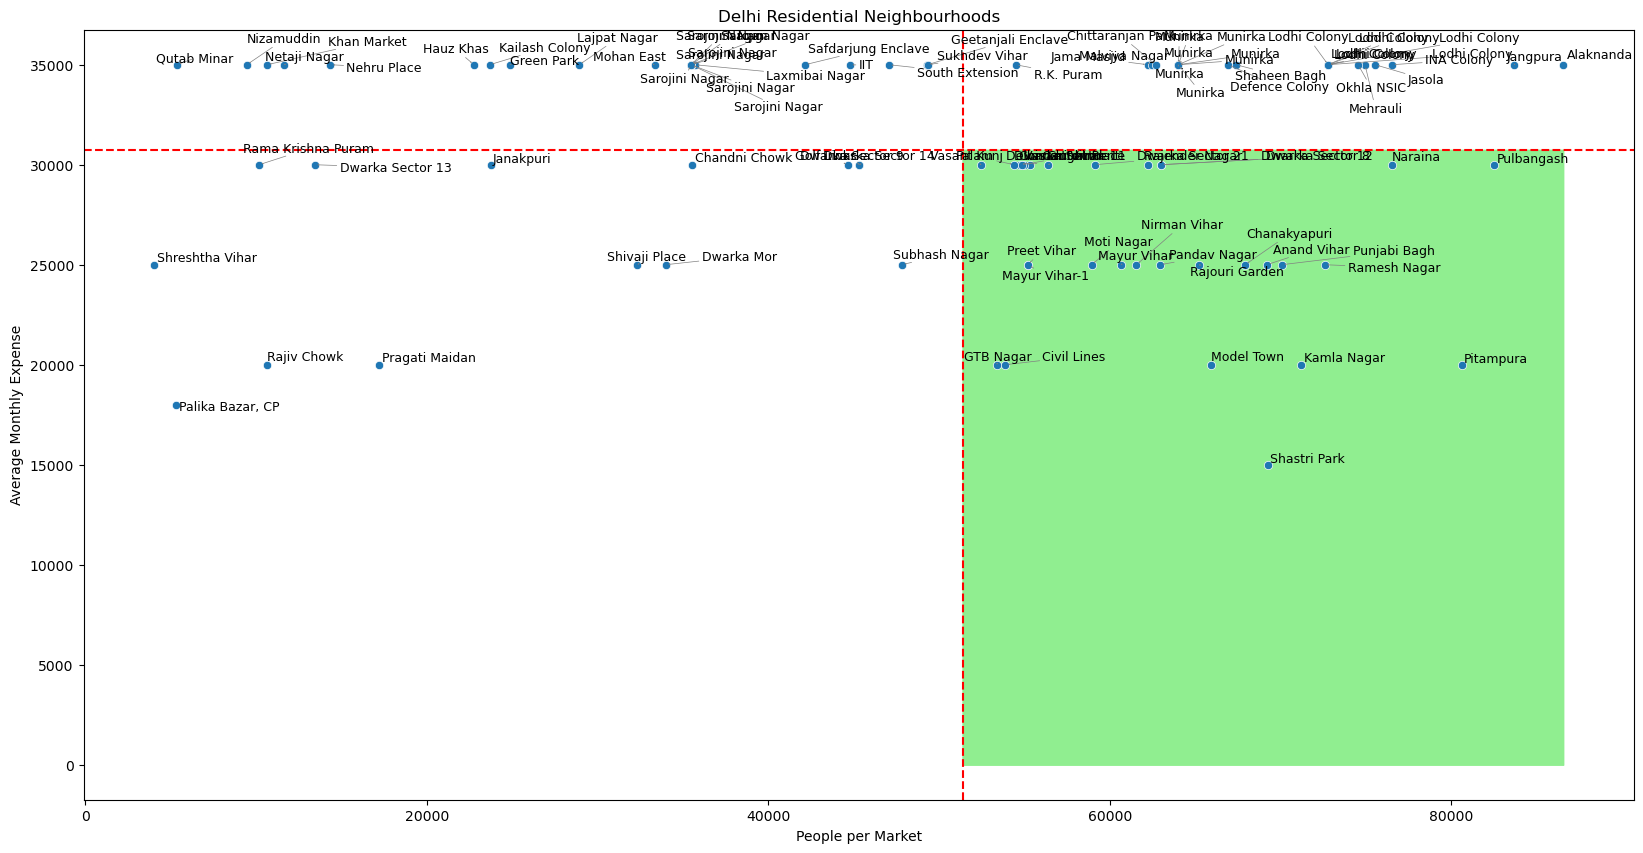

In [41]:
plt.figure(figsize=(20, 10))

# Add horizontal and vertical lines to mark the median values
avg_people_per_market = df_delhi_residential['People per Market'].mean()
max_people_per_market = df_delhi_residential['People per Market'].max()
avg_income = df_delhi_residential['Average Monthly Expense'].mean()

plt.axhline(y=avg_income, color='r', linestyle='--')
plt.axvline(x=avg_people_per_market, color='r', linestyle='--')

# Highlight the optimal quadrant
plt.fill_between(x=np.arange(avg_people_per_market, max_people_per_market), y1=0, y2=avg_income, color='lightgreen')

df_delhi_residential = df_delhi_residential.dropna()

# Function to plot scatter with decluttered labels
def scatter_text(x, y, label, data, title=None, xlabel=None, ylabel=None):
    sns.scatterplot(x=x, y=y, data=data)

    # Adjust labels using adjustText
    texts = []
    for i in range(len(data)):
        texts.append(plt.text(data[x].iloc[i], data[y].iloc[i], data[label].iloc[i], fontsize=9))

    # Automatically adjust text to prevent overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

    plt.show()

# Draw and label the neighbourhood points
scatter_text('People per Market', 'Average Monthly Expense', 'Neighbourhood',
             df_delhi_residential, 
             title='Delhi Residential Neighbourhoods',
             xlabel='People per Market',
             ylabel='Average Monthly Expense')


In [42]:
# Filter the 4th quadrant: People per Market > avg and Average Monthly Expense < avg
quad_4 = df_delhi_residential[
    (df_delhi_residential['People per Market'] > avg_people_per_market) &
    (df_delhi_residential['Average Monthly Expense'] < avg_income)
]

# Sort by 'People per Market' in descending order to get the most right-side points
top_5_rightmost = quad_4.sort_values(by='People per Market', ascending=False).head(5)

# Display the top 5 neighbourhood names
top_5_rightmost[['Neighbourhood']]


,Neighbourhood
8,Pulbangash
0,Pitampura
83,Naraina
92,Ramesh Nagar
2,Kamla Nagar


# Agglomerative Clustering

In [43]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Hierarchical Clustering (AHC)
ahc = AgglomerativeClustering(n_clusters=5, linkage='ward')  # also use 'average' or 'complete' linkage
ahc_labels = ahc.fit_predict(delhi_grouped.drop('Neighbourhood', axis=1))

# Ensure 'Cluster Labels' column doesn't already exist
if 'Cluster Labels' in neighbourhoods_venues_sorted.columns:
    neighbourhoods_venues_sorted.drop(columns=['Cluster Labels'], inplace=True)

# Add AHC clustering labels
neighbourhoods_venues_sorted.insert(0, 'Cluster Labels', ahc_labels)

# Merge with the main dataframe
delhi_merged_ahc = df_neighbourhoods.join(neighbourhoods_venues_sorted.set_index('Neighbourhood'), on='Neighbourhood')

# Print first few cluster labels
print(ahc_labels[:10])

# Print the first few rows
delhi_merged_ahc.head()


[2 0 0 0 0 1 2 2 1 2]


,Neighbourhood,District,Latitude,Longitude,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,North West Delhi,28.719393,77.173273,2,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
1,Ashok Vihar,North West Delhi,28.689766,77.175230,2,ATM,Electronics Store,Bank,Pizzeria,Hair Salon,Gym and Studio,Dessert Shop,Butcher,Gym,Temple
2,Keshav Puram,North West Delhi,28.682776,77.159267,0,ATM,Snack Place,Hair Salon,Restaurant,Structure,Metro Station,Repair Service,Flea Market,High School,Miscellaneous Store
3,Pitampura,North West Delhi,28.695094,77.130706,0,Park,ATM,Restaurant,Apartment or Condo,Clothing Store,Pizzeria,Police Station,Health and Beauty Service,Medical Lab,Tattoo Parlor
4,Rohini,North West Delhi,28.701868,77.098360,2,ATM,Apartment or Condo,Fuel Station,Convenience Store,Bank,Miscellaneous Store,Park,Clothing Store,Assisted Living,Donut Shop


In [44]:
# create map
map_clusters = folium.Map(location=[28.6139, 77.2090], zoom_start=11)

x = np.arange(kclusters)
ys = [i + x + (i*x)**2 for i in range(kclusters)]
colors_array = cm.rainbow(np.linspace(0, 1, len(ys)))
rainbow = [colors.rgb2hex(i) for i in colors_array]

# add markers to the map
markers_colors = []
for lat, lon, area, cluster in zip(delhi_merged_ahc['Latitude'], delhi_merged_ahc['Longitude'], delhi_merged_ahc['Neighbourhood'], delhi_merged_ahc['Cluster Labels']):

    folium.CircleMarker(
        [lat, lon],
        radius=5,
        popup=label,
        color=rainbow[int(cluster)-1],
        fill=True,
        fill_color=rainbow[int(cluster)-1],
        fill_opacity=0.7).add_to(map_clusters)
       
map_clusters

In [45]:
delhi_merged_ahc.loc[delhi_merged_ahc['Cluster Labels'] == 0, delhi_merged_ahc.columns[[0] + list(range(4, delhi_merged_ahc.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
2,Keshav Puram,0,ATM,Snack Place,Hair Salon,Restaurant,Structure,Metro Station,Repair Service,Flea Market,High School,Miscellaneous Store
3,Pitampura,0,Park,ATM,Restaurant,Apartment or Condo,Clothing Store,Pizzeria,Police Station,Health and Beauty Service,Medical Lab,Tattoo Parlor
8,Civil Lines,0,Metro Station,Pizzeria,Government Building,Hospital,Indian Restaurant,ATM,Bus Stop,High School,Mexican Restaurant,Gym and Studio
9,Kamla Nagar,0,Clothing Store,Men's Store,Snack Place,Fast Food Restaurant,Structure,Indian Restaurant,Miscellaneous Store,Fried Chicken Joint,Restaurant,Retail
10,Kashmiri Gate,0,Fast Food Restaurant,Metro Station,ATM,University,Historic and Protected Site,Fried Chicken Joint,Shopping Mall,Automotive Repair Shop,Hindu Temple,Spa
...,...,...,...,...,...,...,...,...,...,...,...,...
149,Paschim Vihar,0,Hotel,Pizzeria,ATM,Indian Restaurant,Housing Development,Coffee Shop,Gym,Food Truck,Preschool,Department Store
151,Punjabi Bagh,0,Indian Restaurant,Lounge,Fast Food Restaurant,Office,Diner,ATM,Gym and Studio,Gym,Electronics Store,Dessert Shop
152,Rajouri Garden,0,Clothing Store,Gym,Ice Cream Parlor,Restaurant,Cosmetics Store,Hair Salon,Shopping Mall,Sikh Temple,Tailor,Coffee Shop
153,Shivaji Place,0,Indian Restaurant,Restaurant,Pizzeria,Lounge,Movie Theater,Shopping Mall,Clothing Store,Coffee Shop,Bowling Alley,Supermarket


In [46]:
delhi_merged_ahc.loc[delhi_merged_ahc['Cluster Labels'] == 1, delhi_merged_ahc.columns[[0] + list(range(4, delhi_merged_ahc.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
16,Majnu-ka-tilla,1,Asian Restaurant,Hotel,Café,ATM,Restaurant,Tibetan Restaurant,Coffee Shop,Korean Restaurant,Bus Station,Office
17,New Aruna Nagar,1,Hotel,Café,Tibetan Restaurant,Restaurant,ATM,Temple,Korean Restaurant,Buddhist Temple,Chinese Restaurant,Gym
18,Aruna Nagar,1,Café,Hotel,Tibetan Restaurant,Restaurant,ATM,Temple,Korean Restaurant,Buddhist Temple,Bus Station,Gym
19,Bhajanpura,1,Travel and Transportation,Pizzeria,Hotel,Clothing Store,Tibetan Restaurant,ATM,Office,Restaurant,Retail,Buddhist Temple
24,Seelampur,1,Tibetan Restaurant,Travel and Transportation,Café,Hotel,ATM,Pizzeria,Buddhist Temple,Office,Retail,Restaurant
28,Karol Bagh,1,Hotel,Jewelry Store,ATM,Clothing Store,Fast Food Restaurant,Fashion Accessories Store,Snack Place,Boutique,Shoe Store,Bank
31,Gole Market,1,Hotel,Indian Restaurant,Office,Hindu Temple,Metro Station,Arts and Crafts Store,ATM,Education,Textiles Store,Bookstore
32,Paharganj,1,Hotel,Bed and Breakfast,Restaurant,Indian Restaurant,Boarding House,Coffee Shop,Gym and Studio,Tennis Court,Church,Board Store
36,Patel Chowk,1,Hotel,Government Building,Metro Station,Bank,Meeting Room,Indian Restaurant,Office,Travel and Transportation,Men's Store,Lounge
37,Janpath,1,Hotel,Metro Station,Spa,Italian Restaurant,Indian Restaurant,Hotel Pool,Event Space,History Museum,Business Center,Travel Agency


In [47]:
delhi_merged_ahc.loc[delhi_merged_ahc['Cluster Labels'] == 2, delhi_merged_ahc.columns[[0] + list(range(4, delhi_merged_ahc.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,2,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
1,Ashok Vihar,2,ATM,Electronics Store,Bank,Pizzeria,Hair Salon,Gym and Studio,Dessert Shop,Butcher,Gym,Temple
4,Rohini,2,ATM,Apartment or Condo,Fuel Station,Convenience Store,Bank,Miscellaneous Store,Park,Clothing Store,Assisted Living,Donut Shop
5,Shalimar Bagh,2,ATM,Indian Restaurant,Automotive Repair Shop,Hospital,Gym and Studio,Bank,Convenience Store,Airport Service,Bakery,Temple
6,Shastri Nagar,2,ATM,Bank,Indian Restaurant,Temple,Gym,Office,Fast Food Restaurant,Rail Station,College Gym,Performing Arts Venue
7,Azadpur,2,ATM,Metro Station,Clothing Store,Factory,Fast Food Restaurant,Hospital,Automotive Repair Shop,Indian Restaurant,Bank,Park
13,Sarai Rohilla,2,ATM,Gym,Dentist,Hotel,Bank,Rail Station,Metro Station,Pizzeria,Camera Store,Men's Store
15,Mukherjee Nagar,2,ATM,Bank,Office,Mobile Phone Store,College and University,Ice Cream Parlor,Hospital,Chinese Restaurant,Hair Salon,Boutique
21,Naveen Shahdara,2,ATM,Metro Station,Pizzeria,Clothing Store,Bank,College Lab,Pharmacy,Retail,Conference Room,Fast Food Restaurant
22,Shahdara,2,ATM,Metro Station,Bank,Clothing Store,Pharmacy,Scenic Lookout,Medical Center,Hair Salon,Chocolate Store,College Cafeteria


In [48]:
delhi_merged_ahc.loc[delhi_merged_ahc['Cluster Labels'] == 3, delhi_merged_ahc.columns[[0] + list(range(4, delhi_merged_ahc.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
159,Vinobapuri,3,Temple,ATM,Non-Profit Organization,Organic Grocery,Optometrist,Office Supply Store,Office Building,Office,Nutritionist,Nursery School


In [49]:
delhi_merged_ahc.loc[delhi_merged_ahc['Cluster Labels'] == 4, delhi_merged_ahc.columns[[0] + list(range(4, delhi_merged_ahc.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
34,Barakhamba Road,4,Office,Bank,Structure,Tea Room,Indian Restaurant,Coffee Shop,Camera Store,Miscellaneous Store,ATM,Gastropub
40,Jhandewalan,4,Office,ATM,Hotel,Structure,Automotive Repair Shop,Temple,Bank,Bed and Breakfast,Diner,Cultural Center
58,Laxmi Nagar,4,Office,Clothing Store,Apartment or Condo,Fast Food Restaurant,Bank,Dessert Shop,Doctor's Office,Cupcake Shop,Bar,High School
82,Saket,4,Structure,Hotel,Office,Bank,Indian Restaurant,Lounge,Men's Store,Chocolate Store,Comedy Club,Resort
87,South East Delhi,4,Office,Coffee Shop,Indian Restaurant,Structure,Coworking Space,Café,Textiles Store,Gym,Men's Store,Tech Startup
106,Govindpuri,4,Office,ATM,Bank,Pizzeria,Pub,Tech Startup,Structure,Business and Professional Services,Snack Place,Coffee Shop
108,Okhla,4,Office,Automotive Repair Shop,Structure,Art Gallery,Bike Rental,Tech Startup,Car Dealership,Performing Arts Venue,Factory,Breakfast Spot
109,Okhla Phase I,4,Office,Automotive Repair Shop,Indian Restaurant,Structure,Clothing Store,ATM,Café,Housing Development,Business and Professional Services,Car Wash and Detail
110,Okhla Phase II,4,Office,Bank,Structure,Hotel,ATM,Bar,Restaurant,Bicycle Store,Health and Beauty Service,Sandwich Spot
111,Sarita Vihar,4,Office,Automotive Repair Shop,Car Dealership,Bank,Dentist,ATM,Park,Tech Startup,Shopping Plaza,Warehouse


In [50]:
# List of residential-related venues
residential_buildings = [
    "ATM", "Indian Restaurant", "Apartment or Condo", "Pizzeria", "Gym",
    "Hair Salon", "Gym and Studio", "Dentist", "Housing Development", "Hospital",
    "Chinese Restaurant", "Jewelry Store", "Park", "Temple", "Bakery",
    "Convenience Store", "Market", "Department Store", "Pharmacy", "Sikh Temple",
    "Hindu Temple", "Church", "Buddhist Temple", "Supermarket"
]

# Select only venue-related columns
venue_columns_ahc = delhi_merged_ahc.columns[5:]

# Count occurrences of residential buildings in each row
delhi_merged_ahc["residential_score"] = delhi_merged_ahc[venue_columns_ahc].apply(
    lambda row: sum(venue in residential_buildings for venue in row), axis=1
)

# Find the cluster with the highest sum of residential buildings
final_cluster_label_ahc = delhi_merged_ahc.groupby("Cluster Labels")["residential_score"].sum().idxmax()

# Select only that cluster
final_cluster_ahc = delhi_merged_ahc[delhi_merged_ahc["Cluster Labels"] == final_cluster_label_ahc]

print(f"Selected Residential Cluster: {final_cluster_label_ahc}")
# print(final_cluster)

Selected Residential Cluster: 0


In [51]:
# From now on, work only with residential neighbourhoods
residential_cluster_id_ahc = final_cluster_label
df_delhi_residential_ahc = df_neighbourhoods[df_neighbourhoods['Neighbourhood'].isin(delhi_merged_ahc.loc[delhi_merged_ahc['Cluster Labels'] == residential_cluster_id_ahc, 'Neighbourhood'])]
df_delhi_residential_ahc

,Neighbourhood,District,Latitude,Longitude
0,Adarsh Nagar,North West Delhi,28.719393,77.173273
1,Ashok Vihar,North West Delhi,28.689766,77.175230
4,Rohini,North West Delhi,28.701868,77.098360
5,Shalimar Bagh,North West Delhi,28.709662,77.159725
6,Shastri Nagar,North West Delhi,28.673304,77.182855
7,Azadpur,North Delhi,28.715464,77.173052
13,Sarai Rohilla,North Delhi,28.665554,77.189486
15,Mukherjee Nagar,North Delhi,28.714262,77.210633
21,Naveen Shahdara,North East Delhi,28.675889,77.285810
22,Shahdara,North East Delhi,28.682740,77.290020


In [52]:
df_delhi_residential_ahc['Number of Markets'] = df_delhi_residential_ahc.apply(getMarketVenues, axis=1)

C:\Users\himde\AppData\Local\Temp\ipykernel_28152\243826560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_delhi_residential_ahc['Number of Markets'] = df_delhi_residential_ahc.apply(getMarketVenues, axis=1)


In [53]:
# Left join with expenditure dataframe
df_delhi_residential_ahc = df_delhi_residential_ahc.merge(df_ame, how='left', on='Neighbourhood')
print(df_delhi_residential_ahc.shape)
df_delhi_residential_ahc.head(10)

(32, 6)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense
0,Adarsh Nagar,North West Delhi,28.719393,77.173273,0,22000.0
1,Ashok Vihar,North West Delhi,28.689766,77.175230,0,20000.0
2,Rohini,North West Delhi,28.701868,77.098360,0,20000.0
3,Shalimar Bagh,North West Delhi,28.709662,77.159725,0,20000.0
4,Shastri Nagar,North West Delhi,28.673304,77.182855,0,30000.0
5,Shastri Nagar,North West Delhi,28.673304,77.182855,0,30000.0
6,Azadpur,North Delhi,28.715464,77.173052,0,20000.0
7,Sarai Rohilla,North Delhi,28.665554,77.189486,1,20000.0
8,Mukherjee Nagar,North Delhi,28.714262,77.210633,1,20000.0
9,Naveen Shahdara,North East Delhi,28.675889,77.285810,0,15000.0


In [76]:
# Left join with population dataframe
df_delhi_residential_ahc = df_delhi_residential_ahc.merge(df_delhi_population, how='left', on='Neighbourhood')
print(df_delhi_residential_ahc.shape)
df_delhi_residential_ahc.tail()

(54, 9)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense,Population_x,People per Market,Population_y
49,Najafgarh,South West Delhi,28.615305,76.982407,0,30000.0,62544.0,62544.0,62544
50,Sagar Pur,South West Delhi,28.605855,77.095518,0,30000.0,32771.0,32771.0,32771
51,Ashok Nagar,West Delhi,28.696358,77.298998,0,25000.0,59850.0,59850.0,59850
52,Mayapuri,West Delhi,28.622587,77.118172,0,25000.0,81500.0,81500.0,81500
53,Tilak Nagar,West Delhi,28.638880,77.087148,4,25000.0,52266.0,13066.0,52266


In [55]:
df_delhi_residential_ahc['People per Market'] = df_delhi_residential_ahc.apply(lambda x: (x['Population'] // x['Number of Markets']) if x['Number of Markets'] > 0 else x['Population'], axis=1)
print(df_delhi_residential_ahc.shape)
df_delhi_residential_ahc.head()

(40, 8)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense,Population,People per Market
0,Adarsh Nagar,North West Delhi,28.719393,77.173273,0,22000.0,NaN,NaN
1,Ashok Vihar,North West Delhi,28.689766,77.175230,0,20000.0,55773.0,55773.0
2,Rohini,North West Delhi,28.701868,77.098360,0,20000.0,127955.0,127955.0
3,Shalimar Bagh,North West Delhi,28.709662,77.159725,0,20000.0,133636.0,133636.0
4,Shastri Nagar,North West Delhi,28.673304,77.182855,0,30000.0,76930.0,76930.0


In [56]:
# df_delhi_residential_ahc.dropna()

3 [-0.46875106 -0.18310224]
4 [0.81733091 0.69602381]
5 [ 0.92665405 -0.13968624]
6 [-0.10154644  0.58017811]
12 [0.86717919 0.9276358 ]
13 [ 0.50307806 -0.02094442]
14 [ 0.79790242 -0.05480997]
15 [0.89975423 0.85636165]
21 [0.92418589 0.61743556]
22 [-0.3427104   0.14889664]
23 [0.35757205 0.55373346]
24 [-0.50335926 -0.45675566]
29 [-0.06026237  0.66886713]
30 [ 0.398339   -0.87815083]
31 [-0.70454967 -0.73699435]
32 [0.97178228 0.19176234]


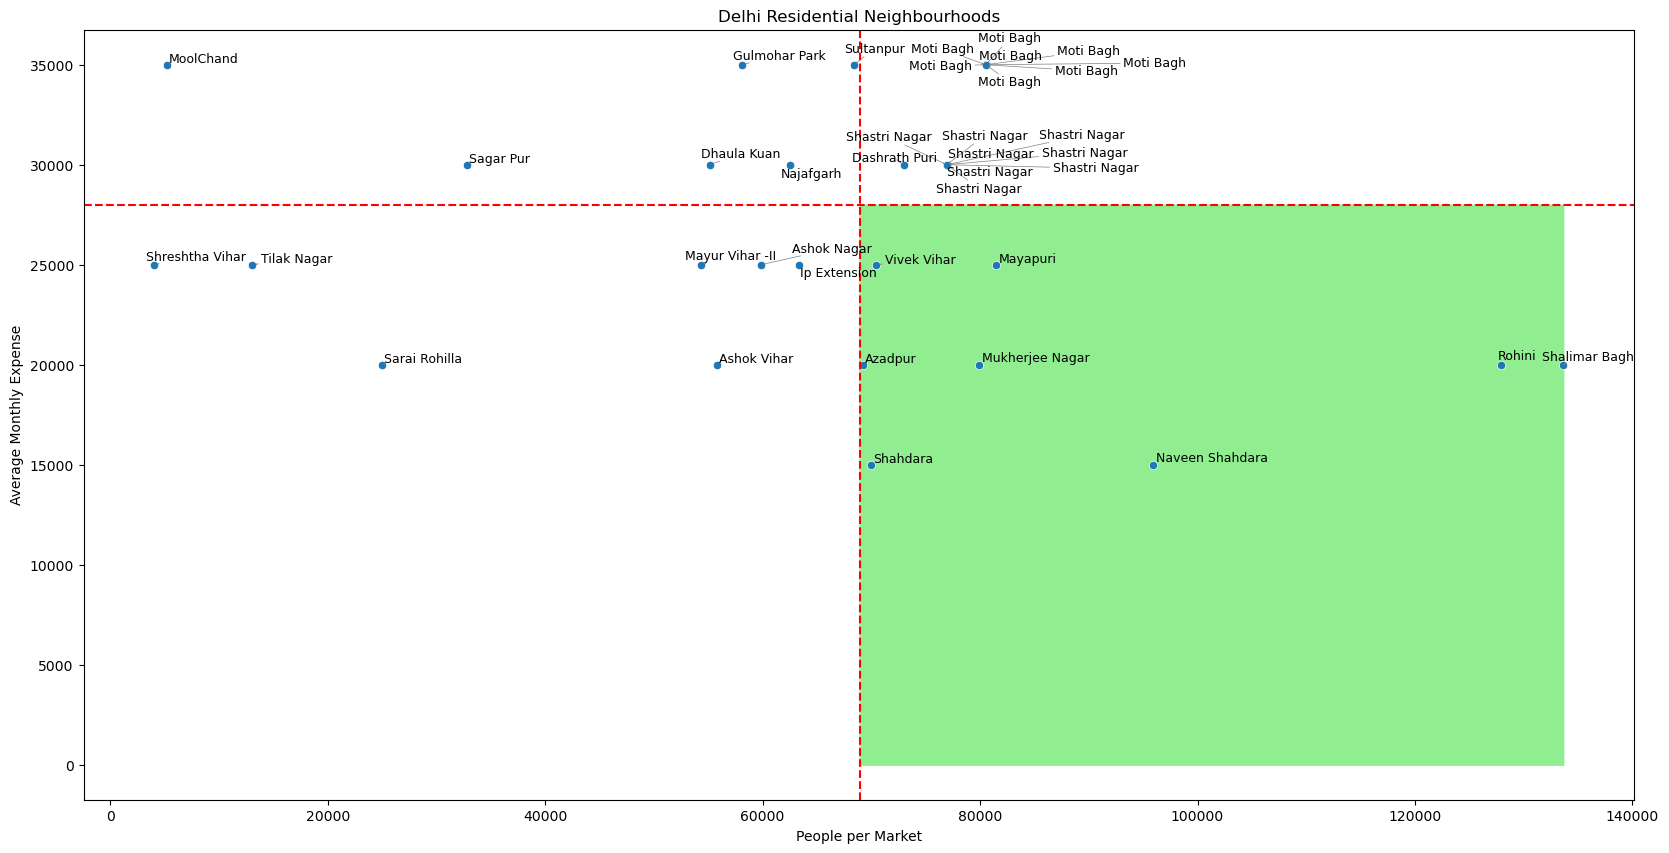

In [57]:
plt.figure(figsize=(20, 10))

# Add horizontal and vertical lines to mark the median values
avg_people_per_market = df_delhi_residential_ahc['People per Market'].mean()
max_people_per_market = df_delhi_residential_ahc['People per Market'].max()
avg_income = df_delhi_residential_ahc['Average Monthly Expense'].mean()

plt.axhline(y=avg_income, color='r', linestyle='--')
plt.axvline(x=avg_people_per_market, color='r', linestyle='--')

# Highlight the optimal quadrant
plt.fill_between(x=np.arange(avg_people_per_market, max_people_per_market), y1=0, y2=avg_income, color='lightgreen')

df_delhi_residential_ahc = df_delhi_residential_ahc.dropna()

# Function to plot scatter with decluttered labels
def scatter_text(x, y, label, data, title=None, xlabel=None, ylabel=None):
    sns.scatterplot(x=x, y=y, data=data)

    # Adjust labels using adjustText
    texts = []
    for i in range(len(data)):
        texts.append(plt.text(data[x].iloc[i], data[y].iloc[i], data[label].iloc[i], fontsize=9))

    # Automatically adjust text to prevent overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

    plt.show()

# Draw and label the neighbourhood points
scatter_text('People per Market', 'Average Monthly Expense', 'Neighbourhood',
             df_delhi_residential_ahc, 
             title='Delhi Residential Neighbourhoods',
             xlabel='People per Market',
             ylabel='Average Monthly Expense')


In [58]:
# Filter the 4th quadrant: People per Market > avg and Average Monthly Expense < avg
quad_4 = df_delhi_residential_ahc[
    (df_delhi_residential_ahc['People per Market'] > avg_people_per_market) &
    (df_delhi_residential_ahc['Average Monthly Expense'] < avg_income)
]

# Sort by 'People per Market' in descending order to get the most right-side points
top_5_rightmost = quad_4.sort_values(by='People per Market', ascending=False).head(5)

# Display the top 5 neighbourhood names
top_5_rightmost[['Neighbourhood']]


,Neighbourhood
3,Shalimar Bagh
2,Rohini
11,Naveen Shahdara
37,Mayapuri
10,Mukherjee Nagar


# DBSCAN

In [59]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize the data
scaler = StandardScaler()
delhi_scaled = scaler.fit_transform(delhi_grouped.drop('Neighbourhood', axis=1))

# Try different values of eps and min_samples
for eps_value in np.arange(0.1, 2, 0.1):  
    dbscan = DBSCAN(eps=eps_value, min_samples=5)  
    labels = dbscan.fit_predict(delhi_scaled)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  
    print(f"eps: {eps_value:.1f}, clusters found: {num_clusters}")

eps: 0.1, clusters found: 0
eps: 0.2, clusters found: 0
eps: 0.3, clusters found: 0
eps: 0.4, clusters found: 0
eps: 0.5, clusters found: 0
eps: 0.6, clusters found: 0
eps: 0.7, clusters found: 0
eps: 0.8, clusters found: 0
eps: 0.9, clusters found: 0
eps: 1.0, clusters found: 0
eps: 1.1, clusters found: 0
eps: 1.2, clusters found: 0
eps: 1.3, clusters found: 0
eps: 1.4, clusters found: 0
eps: 1.5, clusters found: 0
eps: 1.6, clusters found: 0
eps: 1.7, clusters found: 0
eps: 1.8, clusters found: 0
eps: 1.9, clusters found: 0


# HDBSCAN

In [60]:
# !pip install hdbscan
import hdbscan
from sklearn.preprocessing import StandardScaler

# Standardize the data for better clustering performance
scaler = StandardScaler()
scaled_data = scaler.fit_transform(delhi_grouped.drop('Neighbourhood', axis=1))

# Apply HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2, cluster_selection_method='eom')
hdb_labels = hdb.fit_predict(scaled_data)

# Ensure 'Cluster Labels' column doesn't already exist
if 'Cluster Labels' in neighbourhoods_venues_sorted.columns:
    neighbourhoods_venues_sorted.drop(columns=['Cluster Labels'], inplace=True)

# Add HDBSCAN clustering labels
neighbourhoods_venues_sorted.insert(0, 'Cluster Labels', hdb_labels)

# Merge with the main dataframe
delhi_merged_hdbscan = df_neighbourhoods.join(neighbourhoods_venues_sorted.set_index('Neighbourhood'), on='Neighbourhood')

# Print the first few rows
delhi_merged_hdbscan.head()

,Neighbourhood,District,Latitude,Longitude,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,North West Delhi,28.719393,77.173273,0,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
1,Ashok Vihar,North West Delhi,28.689766,77.175230,-1,ATM,Electronics Store,Bank,Pizzeria,Hair Salon,Gym and Studio,Dessert Shop,Butcher,Gym,Temple
2,Keshav Puram,North West Delhi,28.682776,77.159267,-1,ATM,Snack Place,Hair Salon,Restaurant,Structure,Metro Station,Repair Service,Flea Market,High School,Miscellaneous Store
3,Pitampura,North West Delhi,28.695094,77.130706,-1,Park,ATM,Restaurant,Apartment or Condo,Clothing Store,Pizzeria,Police Station,Health and Beauty Service,Medical Lab,Tattoo Parlor
4,Rohini,North West Delhi,28.701868,77.098360,-1,ATM,Apartment or Condo,Fuel Station,Convenience Store,Bank,Miscellaneous Store,Park,Clothing Store,Assisted Living,Donut Shop


In [61]:
# create map
map_clusters = folium.Map(location=[28.6139, 77.2090], zoom_start=11)

x = np.arange(kclusters)
ys = [i + x + (i*x)**2 for i in range(kclusters)]
colors_array = cm.rainbow(np.linspace(0, 1, len(ys)))
rainbow = [colors.rgb2hex(i) for i in colors_array]

# add markers to the map
markers_colors = []
for lat, lon, area, cluster in zip(delhi_merged_hdbscan['Latitude'], delhi_merged_hdbscan['Longitude'], delhi_merged_hdbscan['Neighbourhood'], delhi_merged_hdbscan['Cluster Labels']):

    folium.CircleMarker(
        [lat, lon],
        radius=5,
        popup=label,
        color=rainbow[int(cluster)-1],
        fill=True,
        fill_color=rainbow[int(cluster)-1],
        fill_opacity=0.7).add_to(map_clusters)
       
map_clusters

In [62]:
delhi_merged_hdbscan.loc[delhi_merged_hdbscan['Cluster Labels'] == 0, delhi_merged_hdbscan.columns[[0] + list(range(4, delhi_merged_hdbscan.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
0,Adarsh Nagar,0,ATM,Metro Station,Indian Restaurant,Clothing Store,Convenience Store,Fast Food Restaurant,Hair Salon,Hospital,Bank,Vegan and Vegetarian Restaurant
5,Shalimar Bagh,0,ATM,Indian Restaurant,Automotive Repair Shop,Hospital,Gym and Studio,Bank,Convenience Store,Airport Service,Bakery,Temple
7,Azadpur,0,ATM,Metro Station,Clothing Store,Factory,Fast Food Restaurant,Hospital,Automotive Repair Shop,Indian Restaurant,Bank,Park
21,Naveen Shahdara,0,ATM,Metro Station,Pizzeria,Clothing Store,Bank,College Lab,Pharmacy,Retail,Conference Room,Fast Food Restaurant
22,Shahdara,0,ATM,Metro Station,Bank,Clothing Store,Pharmacy,Scenic Lookout,Medical Center,Hair Salon,Chocolate Store,College Cafeteria
56,Nirman Vihar,0,Clothing Store,Gift Store,Indian Restaurant,ATM,Pizzeria,Chinese Restaurant,Fast Food Restaurant,Jewelry Store,Office,Mobile Phone Store
63,Shreshtha Vihar,0,Indian Restaurant,Temple,ATM,Fast Food Restaurant,Structure,Dentist,Travel and Transportation,Hair Salon,Movie Theater,Spa
64,Vivek Vihar,0,ATM,Pizzeria,Hair Salon,Indian Restaurant,Temple,Metro Station,Apartment or Condo,Flea Market,Bank,Track
85,South Extension,0,Clothing Store,Women's Store,Jewelry Store,Shoe Store,Men's Store,Indian Restaurant,Coffee Shop,Bookstore,Medical Center,Tea Room
95,MoolChand,0,ATM,Factory,Metro Station,Indian Restaurant,Convenience Store,Sikh Temple,Hospital,Hotel,Clothing Store,Design Studio


In [63]:
delhi_merged_hdbscan.loc[delhi_merged_hdbscan['Cluster Labels'] == 1, delhi_merged_hdbscan.columns[[0] + list(range(4, delhi_merged_hdbscan.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
16,Majnu-ka-tilla,1,Asian Restaurant,Hotel,Café,ATM,Restaurant,Tibetan Restaurant,Coffee Shop,Korean Restaurant,Bus Station,Office
17,New Aruna Nagar,1,Hotel,Café,Tibetan Restaurant,Restaurant,ATM,Temple,Korean Restaurant,Buddhist Temple,Chinese Restaurant,Gym
18,Aruna Nagar,1,Café,Hotel,Tibetan Restaurant,Restaurant,ATM,Temple,Korean Restaurant,Buddhist Temple,Bus Station,Gym
19,Bhajanpura,1,Travel and Transportation,Pizzeria,Hotel,Clothing Store,Tibetan Restaurant,ATM,Office,Restaurant,Retail,Buddhist Temple
24,Seelampur,1,Tibetan Restaurant,Travel and Transportation,Café,Hotel,ATM,Pizzeria,Buddhist Temple,Office,Retail,Restaurant


In [64]:
delhi_merged_hdbscan.loc[delhi_merged_hdbscan['Cluster Labels'] == -1, delhi_merged_hdbscan.columns[[0] + list(range(4, delhi_merged_hdbscan.shape[1]))]]

,Neighbourhood,Cluster Labels,1st Most Common Venue,2nd Most Common Venue,3rd Most Common Venue,4th Most Common Venue,5th Most Common Venue,6th Most Common Venue,7th Most Common Venue,8th Most Common Venue,9th Most Common Venue,10th Most Common Venue
1,Ashok Vihar,-1,ATM,Electronics Store,Bank,Pizzeria,Hair Salon,Gym and Studio,Dessert Shop,Butcher,Gym,Temple
2,Keshav Puram,-1,ATM,Snack Place,Hair Salon,Restaurant,Structure,Metro Station,Repair Service,Flea Market,High School,Miscellaneous Store
3,Pitampura,-1,Park,ATM,Restaurant,Apartment or Condo,Clothing Store,Pizzeria,Police Station,Health and Beauty Service,Medical Lab,Tattoo Parlor
4,Rohini,-1,ATM,Apartment or Condo,Fuel Station,Convenience Store,Bank,Miscellaneous Store,Park,Clothing Store,Assisted Living,Donut Shop
6,Shastri Nagar,-1,ATM,Bank,Indian Restaurant,Temple,Gym,Office,Fast Food Restaurant,Rail Station,College Gym,Performing Arts Venue
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Shivaji Place,-1,Indian Restaurant,Restaurant,Pizzeria,Lounge,Movie Theater,Shopping Mall,Clothing Store,Coffee Shop,Bowling Alley,Supermarket
154,Shadipur,-1,Indian Restaurant,Hotel,Pizzeria,Coffee Shop,Chinese Restaurant,Theater,Market,Men's Store,Electronics Store,Gym and Studio
155,Tilak Nagar,-1,ATM,Dentist,Gym and Studio,Bank,Gym,Clothing Store,Business and Professional Services,Flower Store,Food and Beverage Service,Food Truck
156,Vikaspuri,-1,ATM,Sikh Temple,Bank,Other Great Outdoors,Indian Restaurant,Pizzeria,High School,Bar,Butcher,Chinese Restaurant


In [65]:
# List of residential-related venues
residential_buildings = [
    "ATM", "Indian Restaurant", "Apartment or Condo", "Pizzeria", "Gym",
    "Hair Salon", "Gym and Studio", "Dentist", "Housing Development", "Hospital",
    "Chinese Restaurant", "Jewelry Store", "Park", "Temple", "Bakery",
    "Convenience Store", "Market", "Department Store", "Pharmacy", "Sikh Temple",
    "Hindu Temple", "Church", "Buddhist Temple", "Supermarket"
]

# Select only venue-related columns
venue_columns_hdbscan = delhi_merged_hdbscan.columns[5:]

# Count occurrences of residential buildings in each row
delhi_merged_hdbscan["residential_score"] = delhi_merged_hdbscan[venue_columns_hdbscan].apply(
    lambda row: sum(venue in residential_buildings for venue in row), axis=1
)

# Find the cluster with the highest sum of residential buildings
final_cluster_label_hdbscan = delhi_merged_hdbscan.groupby("Cluster Labels")["residential_score"].sum().idxmax()

# Select only that cluster
final_cluster_hdbscan = delhi_merged_hdbscan[delhi_merged_hdbscan["Cluster Labels"] == final_cluster_label_hdbscan ]

print(f"Selected Residential Cluster: {final_cluster_label_hdbscan }")
# print(final_cluster)

Selected Residential Cluster: -1


In [66]:
# From now on, work only with residential neighbourhoods
residential_cluster_id_hdbscan = final_cluster_label_hdbscan
df_delhi_residential_hdbscan= df_neighbourhoods[df_neighbourhoods['Neighbourhood'].isin(delhi_merged_hdbscan.loc[delhi_merged_hdbscan['Cluster Labels'] == residential_cluster_id_hdbscan, 'Neighbourhood'])]
df_delhi_residential_hdbscan

,Neighbourhood,District,Latitude,Longitude
1,Ashok Vihar,North West Delhi,28.689766,77.175230
2,Keshav Puram,North West Delhi,28.682776,77.159267
3,Pitampura,North West Delhi,28.695094,77.130706
4,Rohini,North West Delhi,28.701868,77.098360
6,Shastri Nagar,North West Delhi,28.673304,77.182855
...,...,...,...,...
153,Shivaji Place,West Delhi,28.652545,77.123010
154,Shadipur,West Delhi,28.647020,77.160210
155,Tilak Nagar,West Delhi,28.638880,77.087148
156,Vikaspuri,West Delhi,28.638686,77.071730


In [67]:
df_delhi_residential_hdbscan['Number of Markets'] = df_delhi_residential_hdbscan.apply(getMarketVenues, axis=1)

C:\Users\himde\AppData\Local\Temp\ipykernel_28152\2838083598.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_delhi_residential_hdbscan['Number of Markets'] = df_delhi_residential_hdbscan.apply(getMarketVenues, axis=1)


In [68]:
# Left join with expenditure dataframe
df_delhi_residential_hdbscan= df_delhi_residential_hdbscan.merge(df_ame, how='left', on='Neighbourhood')
print(df_delhi_residential_hdbscan.shape)
df_delhi_residential_hdbscan.tail(10)

(151, 6)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense
141,Mayapuri,West Delhi,28.622587,77.118172,0,25000.0
142,Moti Nagar,West Delhi,28.660736,77.137589,0,25000.0
143,Paschim Vihar,West Delhi,28.670734,77.094191,0,25000.0
144,Punjabi Bagh,West Delhi,28.674891,77.129722,0,25000.0
145,Rajouri Garden,West Delhi,28.646981,77.125658,1,25000.0
146,Shivaji Place,West Delhi,28.652545,77.123010,1,25000.0
147,Shadipur,West Delhi,28.647020,77.160210,0,25000.0
148,Tilak Nagar,West Delhi,28.638880,77.087148,4,25000.0
149,Vikaspuri,West Delhi,28.638686,77.071730,1,NaN
150,Uttam Nagar,West Delhi,28.638412,77.054375,0,25000.0


In [69]:
# Left join with population dataframe
df_delhi_residential_hdbscan = df_delhi_residential_hdbscan.merge(df_delhi_population, how='left', on='Neighbourhood')
print(df_delhi_residential_hdbscan.shape)
df_delhi_residential_hdbscan.head()

(179, 7)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense,Population
0,Ashok Vihar,North West Delhi,28.689766,77.175230,0,20000.0,55773.0
1,Keshav Puram,North West Delhi,28.682776,77.159267,0,20000.0,65433.0
2,Pitampura,North West Delhi,28.695094,77.130706,0,20000.0,80594.0
3,Rohini,North West Delhi,28.701868,77.098360,0,20000.0,127955.0
4,Shastri Nagar,North West Delhi,28.673304,77.182855,0,30000.0,76930.0


In [70]:
df_delhi_residential_hdbscan['People per Market'] = df_delhi_residential_hdbscan.apply(lambda x: (x['Population'] // x['Number of Markets']) if x['Number of Markets'] > 0 else x['Population'], axis=1)
print(df_delhi_residential_hdbscan.shape)
df_delhi_residential_hdbscan.head()

(179, 8)


,Neighbourhood,District,Latitude,Longitude,Number of Markets,Average Monthly Expense,Population,People per Market
0,Ashok Vihar,North West Delhi,28.689766,77.175230,0,20000.0,55773.0,55773.0
1,Keshav Puram,North West Delhi,28.682776,77.159267,0,20000.0,65433.0,65433.0
2,Pitampura,North West Delhi,28.695094,77.130706,0,20000.0,80594.0,80594.0
3,Rohini,North West Delhi,28.701868,77.098360,0,20000.0,127955.0,127955.0
4,Shastri Nagar,North West Delhi,28.673304,77.182855,0,30000.0,76930.0,76930.0


3 [ 0.95913509 -0.42269572]
4 [-0.38450842 -0.52718561]
5 [0.15253688 0.64441928]
6 [-0.22743391 -0.2061522 ]
12 [-0.49460732  0.54440453]
13 [-0.09876967 -0.63527181]
14 [ 0.90576949 -0.68440331]
15 [-0.54714229 -0.83484184]
21 [ 0.56195378 -0.75035743]
22 [-0.68950835 -0.65540203]
23 [-0.84916692  0.94758179]
24 [0.9407781  0.84584454]
29 [-0.00947386  0.19178542]
30 [-0.8233367   0.09586621]
31 [-0.03856894  0.30893873]
32 [0.0106275 0.0990811]


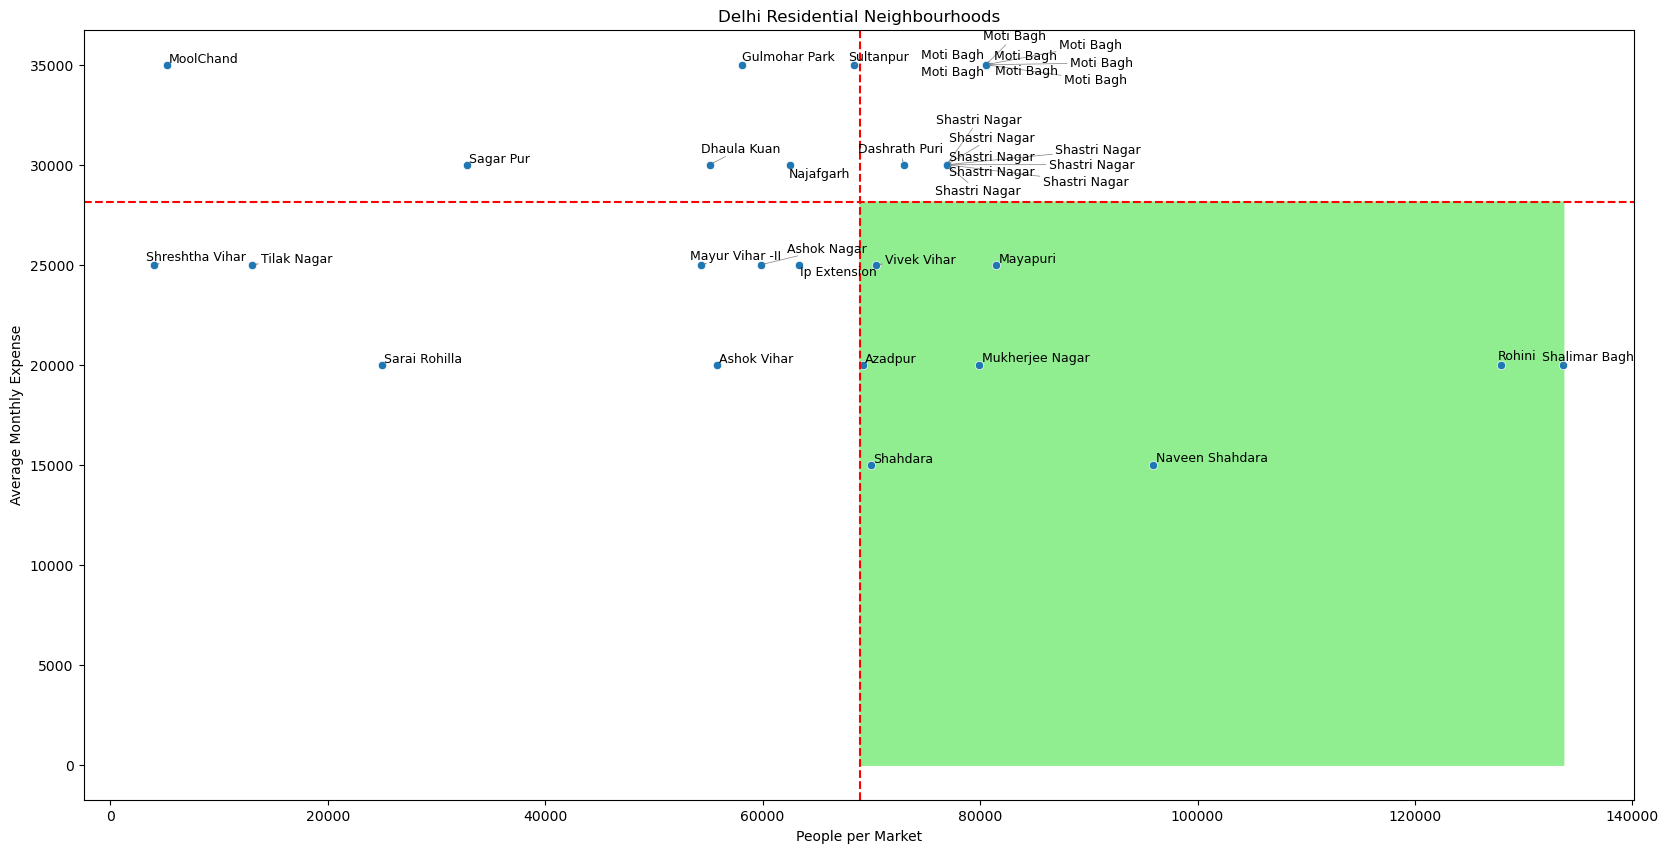

In [73]:
plt.figure(figsize=(20, 10))

# Add horizontal and vertical lines to mark the median values
avg_people_per_market = df_delhi_residential_hdbscan['People per Market'].mean()
max_people_per_market = df_delhi_residential_hdbscan['People per Market'].max()
avg_expense = df_delhi_residential_hdbscan['Average Monthly Expense'].mean()

plt.axhline(y=avg_expense, color='r', linestyle='--')
plt.axvline(x=avg_people_per_market, color='r', linestyle='--')

# Highlight the optimal quadrant
plt.fill_between(x=np.arange(avg_people_per_market, max_people_per_market), y1=0, y2=avg_expense, color='lightgreen')

df_delhi_residential_hdbscan = df_delhi_residential_hdbscan.dropna()

# Function to plot scatter with decluttered labels
def scatter_text(x, y, label, data, title=None, xlabel=None, ylabel=None):
    sns.scatterplot(x=x, y=y, data=data)

    # Adjust labels using adjustText
    texts = []
    for i in range(len(data)):
        texts.append(plt.text(data[x].iloc[i], data[y].iloc[i], data[label].iloc[i], fontsize=9))

    # Automatically adjust text to prevent overlaps
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

    plt.show()

# Draw and label the neighbourhood points
scatter_text('People per Market', 'Average Monthly Expense', 'Neighbourhood',
             df_delhi_residential_hdbscan, 
             title='Delhi Residential Neighbourhoods',
             xlabel='People per Market',
             ylabel='Average Monthly Expense')


In [74]:
# Filter the 4th quadrant: People per Market > avg and Average Monthly Expense < avg
quad_4 = df_delhi_residential_hdbscan[
    (df_delhi_residential_hdbscan['People per Market'] > avg_people_per_market) &
    (df_delhi_residential_hdbscan['Average Monthly Expense'] < avg_expense)
]

# Sort by 'People per Market' in descending order to get the most right-side points
top_5_rightmost = quad_4.sort_values(by='People per Market', ascending=False).head(5)

# Display the top 5 neighbourhood names
top_5_rightmost[['Neighbourhood']]

,Neighbourhood
3,Shalimar Bagh
2,Rohini
11,Naveen Shahdara
37,Mayapuri
10,Mukherjee Nagar


In [72]:
end_time = time.time()
execution_time = end_time - start_time
execution_time_minutes = execution_time / 60

print("Notebook execution finished.")
print("Total execution time:", execution_time_minutes, "minutes")

Notebook execution finished.
Total execution time: 2.123332444826762 minutes
